In [12]:
import pandas as pd

test  = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned_lu.csv")
#df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned.csv")
df = pd.read_csv(r"C:\Users\lclai\OneDrive - LDIG\wesharecare\data_dementia\clean\pitt_clean.csv")


### TRAIN

In [ ]:
df = df[df['label'].isin([0, 1])]
print(df['label'].value_counts())

label
1    253
0    243
Name: count, dtype: int64


In [16]:
df

,subject,age,sex,label,transcript,clean_transcripts
0,0,58,F,0,PAR: the scene is <in the> [/] in the kitchen ...,the scene is in the in the kitchen . the mothe...
1,1,59,F,0,INV: what do you see going on in that picture ...,oh I see the sink is running over . I see the ...
2,2,60,F,0,INV: look at the picture and tell me everythin...,um a boy and a girl are in the kitchen with th...
3,3,61,F,0,INV: look at that picture and I want you to te...,okay . it was summertime and mother and the ch...
4,4,72,M,0,PAR: &=clears:throat wait (un)til I put my gla...,clearsthroat wait until I put my glasses on . ...
...,...,...,...,...,...,...
541,541,73,F,1,PAR: &-uh well ‡ here's the child reaching up ...,uh well heres the child reaching up but hes on...
543,543,71,F,1,PAR: mhm . [+ exc] ▶\nINV: can you tell me now...,mhm . well this one is in the cookie jar . and...
544,544,74,F,1,PAR: the little boy is on the stool which is t...,the little boy is on the stool which is tippin...
545,545,77,M,1,PAR: oh ‡ you want me to tell you . [+ exc] ▶\...,oh you want me to tell you . the mother and he...


In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


def remove_inv_phrases(text):
    if isinstance(text, str):
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        cleaned = [s for s in sentences if not s.startswith("INV")]
        return '. '.join(cleaned) + ('.' if cleaned else '')

df["clean_transcripts"] = df["clean_transcripts"].apply(remove_inv_phrases)

sex = df["sex"].map({"male": 0, "female": 1}).to_numpy().reshape(-1, 1)
age = df["age"].to_numpy().reshape(-1, 1)
texts = df["clean_transcripts"].to_numpy()

y = LabelEncoder().fit_transform(df["label"])
X_raw = np.hstack((sex, age.reshape(-1, 1)))  

X_raw_train, X_raw_test, texts_train, texts_test, y_train, y_test = train_test_split(
    X_raw, texts, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=300)
X_text_train = vectorizer.fit_transform(texts_train).toarray()
X_text_test = vectorizer.transform(texts_test).toarray()

X_train = np.hstack((X_raw_train, X_text_train))
X_test = np.hstack((X_raw_test, X_text_test))

X_train = pd.DataFrame(X_train, columns=['sex','age']+ [f"feature_{i}" for i in range(X_train.shape[1] - 2)])
X_test = pd.DataFrame(X_test, columns=['sex','age']+ [f"feature_{i}" for i in range(X_test.shape[1] - 2)])


C:\Users\lclai\AppData\Local\Temp\ipykernel_6256\2087286127.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_transcripts"] = df["clean_transcripts"].apply(remove_inv_phrases)


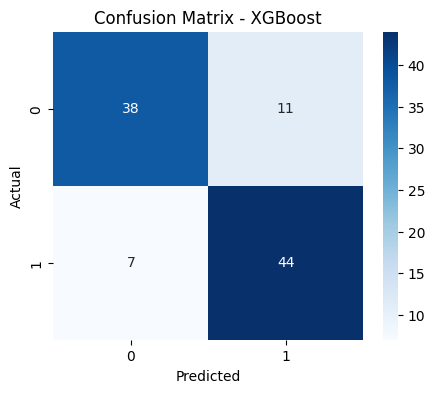

Model: XGBoost
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 10, 'model__n_estimators': 1000, 'model__subsample': 0.8}
Mean AUC (CV=5): 0.8838
STD AUC (CV=5): 0.0470
AUC on Test Set: 0.9084



In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


non_scaled_columns = ['sex']  # no escalar
scaled_columns = [col for col in X_train.columns if col not in non_scaled_columns]


preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaled_columns)
    ],
    remainder='passthrough'  
)


models = {
   # 'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}


param_grids = {
    'Random Forest': {
        'model__n_estimators': [500, 1000],
        'model__max_depth': [None, 2,10],
        'model__min_samples_split': [2,5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'model__n_estimators': [500, 1000],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 6, 10],
        'model__subsample': [0.8, 1.0]
    }
}

results = {}

for model_name in models:
    model = models[model_name]
    param_grid = param_grids[model_name]

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    mean_auc_cv = grid_search.best_score_
    std_auc_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_pred_proba)

    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'best_params': grid_search.best_params_,
        'mean_auc_cv': mean_auc_cv,
        'std_cv': std_auc_cv,
        'auc_test': auc_test,
        'best_model': best_model
    }

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Best Params: {result['best_params']}")
    print(f"Mean AUC (CV=5): {result['mean_auc_cv']:.4f}")
    print(f"STD AUC (CV=5): {result['std_cv']:.4f}")
    print(f"AUC on Test Set: {result['auc_test']:.4f}\n")


## TEST

In [20]:
lu = test.copy()

In [21]:
lu['label'].value_counts()

label
Control        26
Alzheimer's    16
Dementia        6
MCI             2
Conrol          1
Pick's          1
Vascular        1
Aphasia         1
Name: count, dtype: int64

In [22]:
import pandas as pd


lu['label'] = lu['label'].replace({'Conrol': 'Control'})
lu_binary = lu[lu['label'].isin(['Control', "Alzheimer's"])].copy()
lu_binary['label'] = lu_binary['label'].map({'Control': 0, "Alzheimer's": 1})
print(lu_binary['label'].value_counts())


label
0    27
1    16
Name: count, dtype: int64


In [23]:
lu = lu_binary.copy()
lu = lu.dropna()

In [27]:
import pandas as pd
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

sex = lu["sex"].map({"male": 0, "female": 1}).to_numpy().reshape(-1, 1)
age = lu["age"].to_numpy().reshape(-1, 1)
texts = lu["clean_transcripts"].to_numpy()

# Datos numéricos
lu_raw = np.hstack((sex, age))

# Cargar vectorizer entrenado
with open("../models/conversasionals/tfidf_vectorizer.pkl", "rb") as f:
    trained_vectorizer = pickle.load(f)

# Transformar textos
lu_texts = trained_vectorizer.transform(texts).toarray()

# Combinar todo
lu_test = np.hstack((lu_raw, lu_texts))

# Crear dataframe
column_names = ["sex", "age"] + [f"feature_{i}" for i in range(lu_texts.shape[1])]
lu_test = pd.DataFrame(lu_test, columns=column_names)

lu_test = lu_test.dropna()

lu_test.head(5)


,sex,age,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_290,feature_291,feature_292,feature_293,feature_294,feature_295,feature_296,feature_297,feature_298,feature_299
0,0.0,95.0,0.000000,0.0,0.0,0.0,0.0,0.082582,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.123682,0.0,0.000000,0.00000,0.0,0.0
1,0.0,74.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.581900,0.0,0.216034,0.21156,0.0,0.0
2,0.0,75.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.277075,0.00000,0.0,0.0
3,1.0,67.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.100397,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0
4,1.0,69.0,0.131512,0.0,0.0,0.0,0.0,0.000000,0.072843,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.00000,0.0,0.0


Accuracy: 0.36585365853658536
Confusion Matrix:
 [[ 8 18]
 [ 8  7]]


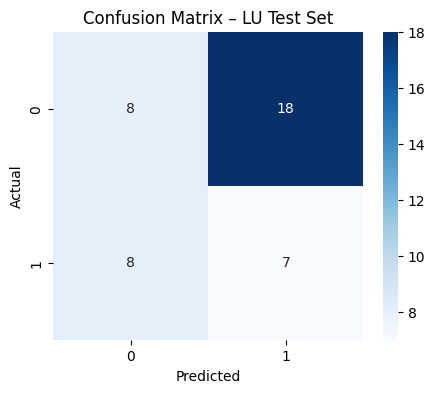

In [28]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_overall = max(results.items(), key=lambda x: x[1]["auc_test"])
best_model = best_overall[1]["best_model"]

clf = best_model.named_steps["model"]

y_pred = clf.predict(lu_test)
y_pred_proba = clf.predict_proba(lu_test)[:, 1]

y_lu = lu[['label']]

accuracy = accuracy_score(y_lu, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_lu, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – LU Test Set")
plt.show()


In [40]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# =============================================================================
# 1. FUNCIONES DE PREPROCESAMIENTO UNIFICADO
# =============================================================================

def remove_inv_phrases(text):
    if isinstance(text, str):
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        cleaned = [s for s in sentences if not s.startswith("INV")]
        return '. '.join(cleaned) + ('.' if cleaned else '')
    return text

def extract_linguistic_features(text):
    if not isinstance(text, str):
        return {
            'num_words': 0,
            'num_sentences': 0,
            'avg_word_length': 0,
            'vocab_richness': 0,
            'repetition_ratio': 0
        }
    
    words = text.split()
    sentences = [s for s in text.split('.') if s.strip()]
    
    features = {
        'num_words': len(words),
        'num_sentences': len(sentences),
        'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
        'vocab_richness': len(set(words)) / len(words) if words else 0,
        'repetition_ratio': (len(words) - len(set(words))) / len(words) if words else 0
    }
    return features

def unified_preprocessing(df, dataset_name="dataset"):
    """Preprocesamiento consistente para ambos datasets"""
    df = df.copy()
    
    # Unificar nombres de columnas
    if 'clean_transcripts' not in df.columns and 'transcript' in df.columns:
        df['clean_transcripts'] = df['transcript']
    
    # Limpiar etiquetas de forma consistente
    label_mapping = {
        'Conrol': 'Control', 
        'Control': 0, 
        "Alzheimer's": 1,
        'Dementia': 1,
        'MCI': 1,
        'Pick\'s': 1,
        'Vascular': 1,
        'Aphasia': 1
    }
    
    df['label'] = df['label'].replace(label_mapping)
    
    # Filtrar solo las etiquetas que nos interesan (0 y 1) y eliminar NaN
    df = df[df['label'].isin([0, 1])].copy()
    df = df.dropna(subset=['label'])
    
    # Aplicar limpieza de texto
    df["clean_transcripts"] = df["clean_transcripts"].apply(remove_inv_phrases)
    
    # Extraer características lingüísticas
    print(f"Extrayendo características lingüísticas para {dataset_name}...")
    linguistic_features = df['clean_transcripts'].apply(extract_linguistic_features)
    linguistic_df = pd.DataFrame(linguistic_features.tolist())
    
    # Combinar con el dataset original
    df = pd.concat([df.reset_index(drop=True), linguistic_df.reset_index(drop=True)], axis=1)
    
    # Mapear sexo a numérico y manejar valores faltantes
    sex_mapping = {'male': 0, 'female': 1, 'M': 0, 'F': 1}
    df['sex'] = df['sex'].map(sex_mapping)
    df['sex'] = df['sex'].fillna(0)  # Asumir male si falta
    
    # Manejar valores faltantes en age
    if 'age' in df.columns:
        df['age'] = df['age'].fillna(df['age'].median())
    
    return df

def analyze_dataset_differences(df1, df2, name1="Pitt", name2="LU"):
    """Analizar diferencias entre datasets"""
    print(f"\n=== COMPARACIÓN {name1} vs {name2} ===")
    
    # Distribución de edades
    print(f"Edad promedio - {name1}: {df1['age'].mean():.1f}, {name2}: {df2['age'].mean():.1f}")
    print(f"Rango edad - {name1}: {df1['age'].min()}-{df1['age'].max()}, {name2}: {df2['age'].min()}-{df2['age'].max()}")
    
    # Distribución de sexo
    print(f"Distribución sexo - {name1}: {dict(df1['sex'].value_counts())}")
    print(f"Distribución sexo - {name2}: {dict(df2['sex'].value_counts())}")
    
    # Distribución de labels
    print(f"Distribución labels - {name1}: {dict(df1['label'].value_counts())}")
    print(f"Distribución labels - {name2}: {dict(df2['label'].value_counts())}")
    
    # Características de texto
    text_len1 = df1['clean_transcripts'].str.len().mean()
    text_len2 = df2['clean_transcripts'].str.len().mean()
    print(f"Longitud promedio texto - {name1}: {text_len1:.1f}, {name2}: {text_len2:.1f}")
    
    # Características lingüísticas
    for feature in ['num_words', 'num_sentences', 'avg_word_length', 'vocab_richness']:
        if feature in df1.columns:
            val1 = df1[feature].mean()
            val2 = df2[feature].mean()
            print(f"{feature} - {name1}: {val1:.2f}, {name2}: {val2:.2f}")

def safe_roc_auc_score(y_true, y_score):
    """Función segura para calcular ROC AUC que maneja casos edge"""
    try:
        # Verificar que tenemos al menos dos clases
        unique_classes = np.unique(y_true)
        if len(unique_classes) < 2:
            print(f"Advertencia: Solo una clase presente: {unique_classes}")
            return 0.5  # Valor aleatorio para una sola clase
        
        # Verificar que no hay NaN
        if np.any(np.isnan(y_true)) or np.any(np.isnan(y_score)):
            print("Advertencia: NaN encontrado en y_true o y_score")
            return 0.5
        
        return roc_auc_score(y_true, y_score)
    except Exception as e:
        print(f"Error calculando ROC AUC: {e}")
        return 0.5

def detailed_error_analysis(y_true, y_pred, y_pred_proba, texts, feature_df=None):
    """Análisis detallado de errores"""
    results = pd.DataFrame({
        'true_label': y_true,
        'predicted_label': y_pred,
        'predicted_prob': y_pred_proba,
        'text_length': [len(str(t)) for t in texts]
    })
    
    if feature_df is not None and len(feature_df) == len(results):
        for col in feature_df.columns:
            results[col] = feature_df[col].values
    
    # Analizar falsos positivos/negativos
    false_positives = results[(results['true_label'] == 0) & (results['predicted_label'] == 1)]
    false_negatives = results[(results['true_label'] == 1) & (results['predicted_label'] == 0)]
    
    print(f"\n=== ANÁLISIS DE ERRORES ===")
    print(f"Falsos positivos: {len(false_positives)}")
    print(f"Falsos negativos: {len(false_negatives)}")
    
    if len(false_positives) > 0:
        print(f"Probabilidad promedio falsos positivos: {false_positives['predicted_prob'].mean():.3f}")
    
    if len(false_negatives) > 0:
        print(f"Probabilidad promedio falsos negativos: {false_negatives['predicted_prob'].mean():.3f}")
    
    return results, false_positives, false_negatives

# =============================================================================
# 2. CARGA Y PREPROCESAMIENTO DE DATOS
# =============================================================================

print("Cargando datasets...")
# Cargar datasets
train_df = pd.read_csv(r"C:\Users\lclai\OneDrive - LDIG\wesharecare\data_dementia\clean\pitt_clean.csv")
test_df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned_lu.csv")

# Preprocesamiento unificado
print("Preprocesando dataset de entrenamiento (Pitt)...")
train_df = unified_preprocessing(train_df, "Pitt")

print("Preprocesando dataset de test (LU)...")
test_df = unified_preprocessing(test_df, "LU")

# Verificar que tenemos datos después del preprocesamiento
print(f"Train shape después de preprocesamiento: {train_df.shape}")
print(f"Test shape después de preprocesamiento: {test_df.shape}")

# Analizar diferencias
analyze_dataset_differences(train_df, test_df, "Pitt", "LU")

# =============================================================================
# 3. PREPARACIÓN DE CARACTERÍSTICAS
# =============================================================================

print("\nPreparando características...")

# Características numéricas y de texto
linguistic_features = ['num_words', 'num_sentences', 'avg_word_length', 'vocab_richness', 'repetition_ratio']
demographic_features = ['sex', 'age']
all_numeric_features = demographic_features + linguistic_features

# Verificar que las características existen en ambos datasets
missing_in_train = [feat for feat in all_numeric_features if feat not in train_df.columns]
missing_in_test = [feat for feat in all_numeric_features if feat not in test_df.columns]

if missing_in_train:
    print(f"Advertencia: Características faltantes en train: {missing_in_train}")
if missing_in_test:
    print(f"Advertencia: Características faltantes en test: {missing_in_test}")

# Preparar datos de entrenamiento
X_raw = train_df[all_numeric_features].to_numpy()
texts_train = train_df["clean_transcripts"].fillna("").to_numpy()
y_train = train_df["label"].to_numpy()

# Preparar datos de test
X_test_raw = test_df[all_numeric_features].to_numpy()
texts_test = test_df["clean_transcripts"].fillna("").to_numpy()
y_test = test_df["label"].to_numpy()

print(f"Distribución de clases en train: {np.unique(y_train, return_counts=True)}")
print(f"Distribución de clases en test: {np.unique(y_test, return_counts=True)}")

# Split de validación del dataset de entrenamiento
X_raw_train, X_raw_val, texts_train_split, texts_val, y_train_split, y_val = train_test_split(
    X_raw, texts_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Vectorización de texto
print("Vectorizando texto...")
vectorizer = TfidfVectorizer(
    max_features=300,  # Reducir para evitar overfitting
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

# Ajustar vectorizer solo con training data
X_text_train = vectorizer.fit_transform(texts_train_split).toarray()
X_text_val = vectorizer.transform(texts_val).toarray()
X_text_test = vectorizer.transform(texts_test).toarray()

# Combinar características
X_train = np.hstack((X_raw_train, X_text_train))
X_val = np.hstack((X_raw_val, X_text_val))
X_test = np.hstack((X_test_raw, X_text_test))

# Crear DataFrames
feature_columns = all_numeric_features + [f"text_feature_{i}" for i in range(X_text_train.shape[1])]
X_train_df = pd.DataFrame(X_train, columns=feature_columns)
X_val_df = pd.DataFrame(X_val, columns=feature_columns)
X_test_df = pd.DataFrame(X_test, columns=feature_columns)

print(f"Dimensiones - Train: {X_train_df.shape}, Val: {X_val_df.shape}, Test: {X_test_df.shape}")

# =============================================================================
# 4. PIPELINE Y ENTRENAMIENTO DEL MODELO
# =============================================================================

print("\nConfigurando pipeline de modelo...")

# Preprocessor para escalar solo características numéricas (no sexo que es binario)
non_scaled_columns = ['sex']  # No escalar
scaled_columns = [col for col in feature_columns if col not in non_scaled_columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaled_columns)
    ],
    remainder='passthrough'
)

# Modelos y parámetros
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        use_label_encoder=False
    )
}

# Parámetros más conservadores para mejor generalización
param_grids = {
    'XGBoost': {
    #    'model__n_estimators': [100, 200],
    #    'model__learning_rate': [0.01, 0.05],
       # 'model__max_depth': [3, 4],
      #  'model__subsample': [0.7, 0.8],
     #   'model__colsample_bytree': [0.7, 0.8],
     #   'model__reg_alpha': [0.1, 1.0],
    #    'model__reg_lambda': [1.0, 2.0]
    }
}

results = {}

for model_name in models:
    print(f"\nEntrenando {model_name}...")
    
    model = models[model_name]
    param_grid = param_grids[model_name]

    # Pipeline con balanceo y selección de características
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectFromModel(LassoCV(cv=3, random_state=42))),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Búsqueda en grid con validación cruzada robusta
    grid_search = GridSearchCV(
        estimator=pipeline, 
        param_grid=param_grid, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc', 
        n_jobs=-1,
        verbose=1
    )
    
    # Entrenar en el split de entrenamiento
    print("Realizando búsqueda de hiperparámetros...")
    grid_search.fit(X_train_df, y_train_split)
    
    # Evaluar en validation set
    best_model = grid_search.best_estimator_
    
    # Predecir en validation set
    y_val_pred_proba = best_model.predict_proba(X_val_df)[:, 1]
    y_val_pred = best_model.predict(X_val_df)
    auc_val = safe_roc_auc_score(y_val, y_val_pred_proba)
    accuracy_val = accuracy_score(y_val, y_val_pred)
    
    def safe_accuracy_score(y_true, y_pred):
        """Función segura para calcular accuracy que maneja formatos inconsistentes"""
        try:
            # Convertir a numpy arrays y asegurar que son enteros
            y_true = np.array(y_true).astype(int)
            y_pred = np.array(y_pred).astype(int)
            
            # Verificar que tienen la misma longitud
            if len(y_true) != len(y_pred):
                print(f"Advertencia: Longitudes diferentes - y_true: {len(y_true)}, y_pred: {len(y_pred)}")
                return 0.0
            
            # Verificar que no hay NaN
            if np.any(np.isnan(y_true)) or np.any(np.isnan(y_pred)):
                print("Advertencia: NaN encontrado en y_true o y_pred")
                return 0.0
            
            return accuracy_score(y_true, y_pred)
        except Exception as e:
            print(f"Error calculando accuracy: {e}")
            return 0.0

    # Y en la sección de evaluación, reemplazar:
    accuracy_val = safe_accuracy_score(y_val, y_val_pred)
    accuracy_test = safe_accuracy_score(y_test, y_test_pred)
    y_test_pred_proba = best_model.predict_proba(X_test_df)[:, 1]
    y_test_pred = best_model.predict(X_test_df)
    auc_test = safe_roc_auc_score(y_test, y_test_pred_proba)
    accuracy_test = safe_accuracy_score(y_test, y_test_pred)
    
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_model': best_model,
        'auc_val': auc_val,
        'accuracy_val': accuracy_val,
        'auc_test': auc_test,
        'accuracy_test': accuracy_test,
        'cv_score': grid_search.best_score_
    }
    
    print(f"{model_name} - Best params: {grid_search.best_params_}")
    print(f"{model_name} - AUC Validation: {auc_val:.4f}, Accuracy: {accuracy_val:.4f}")
    print(f"{model_name} - AUC Test (LU): {auc_test:.4f}, Accuracy: {accuracy_test:.4f}")

# =============================================================================
# 5. EVALUACIÓN Y ANÁLISIS DE RESULTADOS
# =============================================================================

print("\n" + "="*50)
print("RESULTADOS FINALES")
print("="*50)

# Seleccionar el mejor modelo
if results:
    best_model_name = max(results.items(), key=lambda x: x[1]['auc_test'])[0]
    best_result = results[best_model_name]
    best_model = best_result['best_model']

    print(f"\nMEJOR MODELO: {best_model_name}")
    print(f"AUC Validation: {best_result['auc_val']:.4f}")
    print(f"AUC Test (LU): {best_result['auc_test']:.4f}")
    print(f"Accuracy Test: {best_result['accuracy_test']:.4f}")

    # Matriz de confusión en test set
    y_test_pred = best_model.predict(X_test_df)
    
    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {best_model_name}\nLU Test Set")

    # Gráfico de distribución de probabilidades
    plt.subplot(1, 2, 2)
    y_test_pred_proba = best_model.predict_proba(X_test_df)[:, 1]
    for label in [0, 1]:
        mask = y_test == label
        if np.sum(mask) > 0:  # Solo plotear si hay ejemplos de esa clase
            plt.hist(y_test_pred_proba[mask], alpha=0.7, label=f'True Class {label}', bins=20)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Distribution of Predicted Probabilities')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Análisis detallado de errores
    print("\nANÁLISIS DETALLADO DE ERRORES:")
    error_results, fp, fn = detailed_error_analysis(
        y_test, y_test_pred, y_test_pred_proba, 
        test_df['clean_transcripts'].values,
        test_df[all_numeric_features] if all(n in test_df.columns for n in all_numeric_features) else None
    )

    # Guardar el modelo y vectorizer
    print("\nGuardando modelo y vectorizer...")
    with open("best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    with open("tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)

    print("¡Proceso completado!")
else:
    print("No se pudieron entrenar modelos. Verifica los datos.")

Cargando datasets...
Preprocesando dataset de entrenamiento (Pitt)...
Extrayendo características lingüísticas para Pitt...
Preprocesando dataset de test (LU)...
Extrayendo características lingüísticas para LU...
Train shape después de preprocesamiento: (496, 11)
Test shape después de preprocesamiento: (53, 11)

=== COMPARACIÓN Pitt vs LU ===
Edad promedio - Pitt: 68.4, LU: 79.6
Rango edad - Pitt: 46-90, LU: 47.0-99.0
Distribución sexo - Pitt: {1: 322, 0: 174}
Distribución sexo - LU: {1: 32, 0: 21}
Distribución labels - Pitt: {1: 253, 0: 243}
Distribución labels - LU: {1: 27, 0: 26}
Longitud promedio texto - Pitt: 532.5, LU: 524.5
num_words - Pitt: 105.64, LU: 105.98
num_sentences - Pitt: 12.86, LU: 11.43
avg_word_length - Pitt: 4.09, LU: 3.96
vocab_richness - Pitt: 0.66, LU: 0.68

Preparando características...
Distribución de clases en train: (array([0, 1], dtype=int64), array([243, 253], dtype=int64))
Distribución de clases en test: (array([0, 1], dtype=object), array([26, 27], dtype=

c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.361e-03, tolerance: 6.600e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.724e-02, tolerance: 6.600e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regula

Error calculando ROC AUC: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
XGBoost - Best params: {}
XGBoost - AUC Validation: 0.8848, Accuracy: 0.8300
XGBoost - AUC Test (LU): 0.5000, Accuracy: 0.6415

RESULTADOS FINALES

MEJOR MODELO: XGBoost
AUC Validation: 0.8848
AUC Test (LU): 0.5000
Accuracy Test: 0.6415


ValueError: Classification metrics can't handle a mix of unknown and binary targets